In [5]:
import pandas as pd

CSV_PATH = "/home/agbelgaid/Documents/WORKSPACE/DataCollection/SoilHive/data/combined_output_data_points.csv"


def read_csv_and_get_columns(path: str):
    """
    Read the CSV file and return:
    - the DataFrame
    - the list of column names
    """
    df = pd.read_csv(path, low_memory=False)
    columns = df.columns.tolist()
    return df, columns
df, cols = read_csv_and_get_columns(CSV_PATH)

print("Columns:")
print(cols)


Columns:
['id', 'lat', 'lon', 'property', 'original_name', 'upper_depth_cm', 'lower_depth_cm', 'value', 'unit', 'sampling_date', 'license', 'h3_index', 'publication_date', 'data_source']


In [8]:
import pandas as pd
import geopandas as gpd

def add_country_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add 'country' and 'continent' columns using spatial join.
    Requires lat and lon columns.
    """

    if "lat" not in df.columns or "lon" not in df.columns:
        raise ValueError("Dataset must contain 'lat' and 'lon' columns.")

    # Load Natural Earth countries (from official URL)
    url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(url)

    world = world[["geometry", "ADMIN", "CONTINENT"]]
    world = world.rename(columns={
        "ADMIN": "country",
        "CONTINENT": "continent"
    })

    # Convert points to GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"
    )

    # Spatial join
    joined = gpd.sjoin(gdf, world, how="left", predicate="within")

    joined["country"] = joined["country"].fillna("Unknown")
    joined["continent"] = joined["continent"].fillna("Unknown")

    return pd.DataFrame(
        joined.drop(columns=["geometry", "index_right"], errors="ignore")
    )


def get_dataframe_by_country(df: pd.DataFrame, country_name: str) -> pd.DataFrame:
    """
    Case-insensitive country filtering.
    Example: 'brazil' will match 'Brazil'
    """

    if "country" not in df.columns:
        raise ValueError("DataFrame does not contain 'country' column.")

    return df[df["country"].str.lower() == country_name.lower()].copy()

df = add_country_column(df)

print("Columns after enrichment:")
print(df.columns.tolist())


Columns after enrichment:
['id', 'lat', 'lon', 'property', 'original_name', 'upper_depth_cm', 'lower_depth_cm', 'value', 'unit', 'sampling_date', 'license', 'h3_index', 'publication_date', 'data_source', 'country', 'continent']


In [9]:
brazil_df = get_dataframe_by_country(df, "Brazil")
print("Number of rows for Brazil:", len(brazil_df))

Number of rows for Brazil: 567


In [ ]:
brazil_df

,id,lat,lon,property,original_name,upper_depth_cm,lower_depth_cm,value,unit,sampling_date,license,h3_index,publication_date,data_source,country,continent
63638,3503,-8.60,-73.350000,CEC,ecec,45.0,70.0,5.3,cmolc/kg,1977.0,CC BY-NC 4.0,838f4dfffffffff,2023-01-01,WoSIS,Brazil,South America
63639,3504,-8.60,-73.350000,CEC,ecec,150.0,170.0,2.8,cmolc/kg,1977.0,CC BY-NC 4.0,838f4dfffffffff,2023-01-01,WoSIS,Brazil,South America
63640,3505,-8.60,-73.350000,CEC,ecec,100.0,150.0,2.3,cmolc/kg,1977.0,CC BY-NC 4.0,838f4dfffffffff,2023-01-01,WoSIS,Brazil,South America
63641,3506,-8.60,-73.350000,CEC,ecec,20.0,45.0,5.0,cmolc/kg,1977.0,CC BY-NC 4.0,838f4dfffffffff,2023-01-01,WoSIS,Brazil,South America
63642,3507,-8.60,-73.350000,CEC,ecec,0.0,5.0,5.9,cmolc/kg,1977.0,CC BY-NC 4.0,838f4dfffffffff,2023-01-01,WoSIS,Brazil,South America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
874901,8710,-32.65,-53.266667,clay,clay,23.0,32.0,12.0,g/100g,1982.0,CC BY 4.0,83c2d2fffffffff,2023-01-01,WoSIS,Brazil,South America
874902,8711,-32.65,-53.266667,clay,clay,32.0,48.0,32.4,g/100g,1982.0,CC BY 4.0,83c2d2fffffffff,2023-01-01,WoSIS,Brazil,South America
874903,8712,-32.65,-53.266667,clay,clay,0.0,23.0,14.3,g/100g,1982.0,CC BY 4.0,83c2d2fffffffff,2023-01-01,WoSIS,Brazil,South America
874904,8713,-32.65,-53.266667,clay,clay,48.0,78.0,32.6,g/100g,1982.0,CC BY 4.0,83c2d2fffffffff,2023-01-01,WoSIS,Brazil,South America


**1.0 Number of records by feature**

In [22]:
brazil_df['sampling_date'].unique()

array([1977.,   nan, 1979., 1982.])

In [17]:
# Count records per feature
records_by_feature = (
    brazil_df
    .groupby("property")
    .size()
    .reset_index(name="record_count")
    .sort_values("record_count", ascending=False)
)

print(records_by_feature)

         property  record_count
13             pH           100
1             CEC            93
12            occ            65
15           silt            64
11           clay            63
14           sand            63
8               N            36
4           CaCO3            20
5              EC            20
10  WR_volumetric            11
2              CF             7
3              Ca             6
0              BD             6
7              Mg             6
9              Na             5
6               K             2


In [23]:
brazil_df["year"] = (
    brazil_df["sampling_date"]
    .dropna()
    .astype(int)
)

records_feature_year = (
    brazil_df
    .dropna(subset=["year"])
    .groupby(["property", "year"])
    .size()
    .reset_index(name="record_count")
    .sort_values(["property", "year"])
)

print(records_feature_year)

         property    year  record_count
0              BD  1982.0             6
1             CEC  1977.0            11
2             CEC  1979.0             9
3             CEC  1982.0            17
4              CF  1982.0             7
5           CaCO3  1982.0             5
6              EC  1982.0            13
7               N  1982.0            11
8   WR_volumetric  1982.0            11
9            clay  1977.0            10
10           clay  1979.0             9
11           clay  1982.0            12
12            occ  1977.0            11
13            occ  1979.0             9
14            occ  1982.0            13
15             pH  1977.0            22
16             pH  1979.0            18
17             pH  1982.0            26
18           sand  1977.0            11
19           sand  1979.0             8
20           sand  1982.0            12
21           silt  1977.0            11
22           silt  1979.0             9
23           silt  1982.0            12


year           1977.0  1979.0  1982.0
property                             
BD                  0       0       6
CEC                11       9      17
CF                  0       0       7
CaCO3               0       0       5
EC                  0       0      13
N                   0       0      11
WR_volumetric       0       0      11
clay               10       9      12
occ                11       9      13
pH                 22      18      26
sand               11       8      12
silt               11       9      12


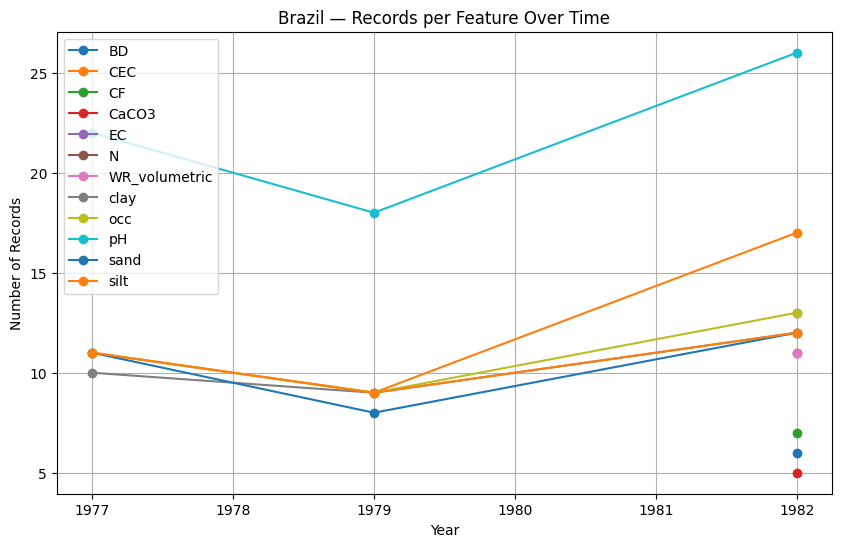

In [24]:
pivot_feature_year = (
    records_feature_year
    .pivot(index="property", columns="year", values="record_count")
    .fillna(0)
    .astype(int)
)

print(pivot_feature_year)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

for feature in records_feature_year["property"].unique():
    subset = records_feature_year[
        records_feature_year["property"] == feature
    ]
    plt.plot(
        subset["year"],
        subset["record_count"],
        marker="o",
        label=feature
    )

plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.title("Brazil — Records per Feature Over Time")
plt.legend()
plt.grid(True)
plt.show()